# Homograph / Polysemy Entity Absorption Testbed — Demo

This artifact is a **pure-CPU, text-only dataset** for studying *feature absorption* in sparse
autoencoders (SAEs): when a single SAE latent that should fire for a parent concept (e.g. **is-a-city**)
silently fails on tokens whose surface form carries a strong *competing* sense.

It builds **four is-a hierarchies** whose entity tokens are homographs:

| hierarchy | parent concept | example entities | competing sense |
|---|---|---|---|
| `city` | is-a-city | Phoenix, Mobile, Reading, Paris, Mercury | mythical bird / adjective / planet |
| `month` | is-a-month | May, March, August, April | modal verb / to march / "august" |
| `given_name` | is-a-given-name | Grace, Hope, Will, Rose, Frank | grace / hope / modal / flower |
| `brand` | is-a-brand | Apple, Amazon, Shell, Target, Java | fruit / river / seashell / island |

Each hierarchy ships three coordinated components: **(A) content-flip** minimal pairs (parent present
vs absent, surface-matched), **(B) surface-flip** pairs (concept fixed, surface varied), and
**(C) a diagnostic corpus** of real windows. The key control is the **`homograph_competitor`** negative
family — the *same surface token in its non-target sense* (lowercase `phoenix`, `Joaquin Phoenix`) — the
matched hard negative that makes a *suppressed parent* visible.

**All labels come purely from surface form / regex / gazetteer / local context — never a model.** This
"degenerate-construction guard" is what keeps absorption an *empirical* finding rather than something
baked into the data.

This notebook **(1)** loads the shipped demo slice (one hierarchy), **(2)** re-runs the real
construction core — the homograph gazetteers, the surface-form detectors, and the templated pair
generators — and **(3)** verifies the surface-form labels reproduce. The heavy passes in the full
`data.py` pipeline (pile-uncopyrighted streaming, LLM judging, gemma-2-2b tokenization) need
network/GPU/API and are omitted; the demo loads the pre-built slice instead.


## Setup

### Install dependencies

In [1]:
# Install dependencies. On Colab the core scientific stack is pre-installed (and re-installing it
# corrupts the loaded C extensions), so those go behind the `google.colab` guard; the small text-only
# helpers (loguru / wordfreq / geonamescache) are not on Colab and are installed everywhere.
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# NOT pre-installed on Colab -> always install
_pip('loguru==0.7.3', 'wordfreq==3.1.1', 'geonamescache==2.0.0')

# Pre-installed on Colab -> install locally only, pinned to Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


### Imports

In [2]:
# Original construction core imports (calendar/re drive the gazetteers and surface regexes),
# plus loguru for the build logs and pandas/matplotlib for the demo summary at the end.
from __future__ import annotations
import calendar
import re
import sys
import json
import random
import urllib.request
from collections import Counter, defaultdict

from loguru import logger
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NumPy 2.0 compatibility shims (harmless if not needed)
if not hasattr(np, "alltrue"): np.alltrue = np.all
if not hasattr(np, "product"): np.product = np.prod


### Load the demo data

GitHub URL with a local fallback (Colab-compatible).

In [3]:
# Load the curated demo slice (one hierarchy, <=100 examples) from GitHub, with a local fallback so
# the notebook also runs offline. The full four-hierarchy dataset is produced by data.py (pile-streaming
# + LLM judging + gemma tokenization) and shipped as full_data_out.json; here we use the mini slice.
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-5/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
data = load_data()
ds = data["datasets"][0]
print("dataset:", ds["dataset"])
print("metadata:", json.dumps(data["metadata"], indent=2)[:600])
print("n examples:", len(ds["examples"]))


dataset: city_homograph_absorption
metadata: {
  "title": "Homograph/Polysemy Entity Absorption Testbed \u2014 mini demo slice (city hierarchy)",
  "note": "Curated <=100-example slice of ONE hierarchy (city_homograph_absorption) for the demo notebook. Content-flip + surface-flip pairs are produced by the real templated generators; the diagnostic corpus rows are hand-written windows labelled by the same surface-form regex detectors used on the pinned pile-uncopyrighted corpus.",
  "seed": 20240617,
  "hierarchy": "city",
  "parent_concept": "the name of a city",
  "wordfreq_ok": true,
  "n_entities_in_hierarchy": 23,
  "component_counts"
n examples: 52


## Config

All tunable parameters live here. Defaults are minimal; the live re-build is pure-CPU and scales freely.

In [5]:
# ============================ CONFIG (tunable parameters) ============================
# Start at the absolute minimum that still produces output; scale up freely (pure-CPU, fast).
SEED = 20240617                 # original fixed seed (reproducibility)
DEMO_HIERARCHY = "city"         # which of the four is-a hierarchies to demonstrate

# Templated-pair generation sizes for the LIVE re-build demo. The full build sweeps the entire
# gazetteer (all 23 city entities x all frames); these are pure-CPU and scale freely (~0 runtime cost).
# Start small (e.g. 8 / 6) and raise toward a full sweep; 20 / 12 covers most of the city gazetteer.
N_CONTENT_PAIRS = 20            # content-flip minimal pairs to generate (orig: full gazetteer sweep)
N_SURFACE_PAIRS = 12           # surface-flip pairs to generate
# ====================================================================================

# Original four-hierarchy constants (from build_dataset.py):
HIERARCHIES = ["city", "month", "given_name", "brand"]
DATASET_NAME = {
    "city": "city_homograph_absorption",
    "month": "month_name_absorption",
    "given_name": "given_name_absorption",
    "brand": "brand_homograph_absorption",
}
PARENT_CONCEPT = {
    "city": "the name of a city",
    "month": "a calendar month",
    "given_name": "a person's given name",
    "brand": "a company or brand name",
}
print("hierarchy:", DEMO_HIERARCHY, "| parent concept =", PARENT_CONCEPT[DEMO_HIERARCHY])


hierarchy: city | parent concept = the name of a city


## Construction core — Part 1: homograph strength + entity gazetteers

`homograph_strength` is the **wordfreq Zipf frequency of the lowercase competing word** (higher = stronger competing sense). The gazetteers list each entity with its competing sense gloss and any high-precision capitalised competitor cues (e.g. `Joaquin Phoenix`). Cross-hierarchy collisions (Dawn, Chase, Jordan, Mercury, Paris) are recorded explicitly.

In [6]:
# ----------------------------------------------------------------------------- homograph strength (wordfreq)
try:
    from wordfreq import zipf_frequency

    def homograph_strength(word: str) -> float:
        try:
            return round(float(zipf_frequency(word.lower(), "en")), 3)
        except Exception:
            return 0.0
    WORDFREQ_OK = True
except Exception as e:  # pragma: no cover - fallback path
    logger.warning(f"[wordfreq] unavailable ({repr(e)[:80]}); using neutral 'medium' tag")
    WORDFREQ_OK = False

    def homograph_strength(word: str) -> float:
        return 4.0  # neutral 'medium' tag when wordfreq missing


# ----------------------------------------------------------------------------- entity gazetteers
# Each city entity: (surface, competitor_word_lowercase, competitor_gloss, lc_is_competitor, [special_regex])
CITY_RAW = [
    ("Phoenix",   "phoenix",   "mythical bird / comeback / Joaquin Phoenix", True,
     [r"Joaquin\s+Phoenix", r"(?:rose|rise|rising|risen|rises)\b.{0,25}\bashes\b"]),
    ("Mobile",    "mobile",    "adjective 'mobile' / mobile phone",          True, []),
    ("Reading",   "reading",   "gerund of 'read'",                           True, []),
    ("Bath",      "bath",      "a bathtub / bathing",                        True, []),
    ("Nice",      "nice",      "adjective 'nice' (pleasant)",                True, []),
    ("Buffalo",   "buffalo",   "the animal",                                 True, []),
    ("Hull",      "hull",      "the hull of a ship",                         True, []),
    ("Cork",      "cork",      "a bottle cork",                              True, []),
    ("Split",     "split",     "to split / a split",                         True, []),
    ("Bend",      "bend",      "to bend / a bend",                           True, []),
    ("Worth",     "worth",     "value / 'worth' preposition",                True, []),
    ("Sandy",     "sandy",     "covered in sand",                            True, []),
    ("Surprise",  "surprise",  "a surprise",                                 True, []),
    ("Cologne",   "cologne",   "perfume / eau de cologne",                   True, [r"eau\s+de\s+[Cc]ologne"]),
    ("Mercury",   "mercury",   "planet / element / Freddie Mercury",         True,
     [r"Freddie\s+Mercury", r"\bMercury\b\s+(?:is|orbits|poisoning|vapou?r|thermometer|the\s+planet)"]),
    ("Jackson",   "jackson",   "surname / Michael Jackson",                  False,
     [r"(?:Michael|Janet|Andrew|Samuel|Stonewall|Peter|Phil|Reggie|Jesse)\s+Jackson"]),
    ("Columbus",  "columbus",  "Christopher Columbus",                       False,
     [r"Christopher\s+Columbus", r"\bColumbus\s+(?:discovered|sailed|Day)\b"]),
    ("Cleveland", "cleveland", "Grover Cleveland (surname)",                 False,
     [r"(?:Grover|President)\s+Cleveland"]),
    ("Florence",  "florence",  "given name / Florence Nightingale",          False,
     [r"Florence\s+Nightingale", r"(?:Mr|Mrs|Ms|Miss|Aunt|Lady)\.?\s+Florence"]),
    ("Sydney",    "sydney",    "given name",                                 False,
     [r"(?:Mr|Mrs|Ms|Miss|Aunt)\.?\s+Sydney"]),
    ("Paris",     "paris",     "Greek myth / Paris Hilton",                  False,
     [r"Paris\s+Hilton", r"\bParis\b\s+(?:of\s+Troy|abducted|the\s+prince)"]),
    ("Jordan",    "jordan",    "the river / Michael Jordan",                 False,
     [r"Michael\s+Jordan", r"(?:River|river)\s+Jordan", r"\bJordan\s+(?:River|scored|dunked)\b"]),
    ("Hollywood", "hollywood", "the film industry",                          False,
     [r"Hollywood\s+(?:film|films|movie|movies|star|stars|studio|studios|blockbuster|actor|actress|producer|director|glamou?r|ending)"]),
]

# Months: all 12; competitor cues concentrate on the homograph-strong (May/March/August + name-months).
MONTH_NAMES = [calendar.month_name[i] for i in range(1, 13)]
MONTH_SPECIAL = {
    "May": (False, [r"\bMay\s+(?:I|we|you|he|she|it|they|the|not|have|be|or|well|come|wish|find|"
                    r"seem|cause|require|include|vary|differ|need|want|also|still|even|never|only|"
                    r"please|God|your|our|their|his|her|its|this|that|these|those|a|an)\b"]),
    "March": (True, []),    # lowercase 'march/marched/marching/marches' added below
    "August": (False, [r"\baugust\s+(?:body|bodies|assembly|presence|institution|institutions|"
                       r"gathering|personage|occasion|company|group|members?|tradition)\b"]),
    "April": (False, [r"(?:Mr|Mrs|Ms|Miss|Aunt)\.?\s+April", r"April\s+(?:O'Neil|Ludgate)"]),
    "June": (False, [r"(?:Mr|Mrs|Ms|Miss|Aunt)\.?\s+June", r"June\s+(?:Carter|Cleaver)"]),
}
MONTH_COMP_WORD = {m: m.lower() for m in MONTH_NAMES}
MONTH_COMP_GLOSS = {
    "May": "modal verb 'may'", "March": "to march / a protest march",
    "August": "adjective 'august' (distinguished)", "April": "given name",
    "June": "given name",
}

GIVEN_RAW = [  # (surface, competitor_word, gloss) -- all lc_is_competitor=True (word-names)
    ("Grace", "grace", "gracefulness / elegance"),
    ("Hope", "hope", "to hope / hope (noun)"),
    ("Faith", "faith", "religious faith"),
    ("Joy", "joy", "joy (emotion)"),
    ("Mark", "mark", "a mark / to mark"),
    ("Bill", "bill", "an invoice / a bird's beak"),
    ("Will", "will", "modal verb 'will' / a testament"),
    ("Rose", "rose", "the flower / past tense of 'rise'"),
    ("Frank", "frank", "adjective 'frank' / to frank"),
    ("Pat", "pat", "to pat"),
    ("Dawn", "dawn", "daybreak"),
    ("Summer", "summer", "the season"),
    ("Autumn", "autumn", "the season"),
    ("Crystal", "crystal", "a crystal"),
    ("Daisy", "daisy", "the flower"),
    ("Lily", "lily", "the flower"),
    ("Violet", "violet", "the flower / colour"),
    ("Ivy", "ivy", "the plant"),
    ("Holly", "holly", "the plant"),
    ("Rosemary", "rosemary", "the herb"),
    ("Pearl", "pearl", "the gem"),
    ("Ruby", "ruby", "the gem / colour"),
    ("Art", "art", "art"),
    ("Earl", "earl", "a noble rank"),
    ("Jack", "jack", "to jack / a playing card / a device"),
    ("Drew", "drew", "past tense of 'draw'"),
    ("Sky", "sky", "the sky"),
    ("Reed", "reed", "a reed (plant)"),
    ("Chase", "chase", "to chase"),
    ("Wade", "wade", "to wade"),
    ("Cliff", "cliff", "a cliff"),
    ("Dean", "dean", "an academic dean"),
    ("Robin", "robin", "the bird"),
    ("Carol", "carol", "a carol / to sing"),
]

BRAND_RAW = [  # (surface, competitor_word, gloss) -- all lc_is_competitor=True (word-brands)
    ("Apple", "apple", "the fruit"),
    ("Amazon", "amazon", "the river / rainforest / warrior"),
    ("Shell", "shell", "a seashell / a shell"),
    ("Gap", "gap", "a gap"),
    ("Dove", "dove", "the bird / past tense of 'dive'"),
    ("Target", "target", "a target / to aim at"),
    ("Orange", "orange", "the fruit / the colour"),
    ("Subway", "subway", "the underground railway"),
    ("Tide", "tide", "the ocean tide"),
    ("Corona", "corona", "a crown / the sun's corona"),
    ("Visa", "visa", "a travel visa"),
    ("Polo", "polo", "the sport"),
    ("Puma", "puma", "the animal"),
    ("Jaguar", "jaguar", "the animal"),
    ("Caterpillar", "caterpillar", "the insect"),
    ("Dawn", "dawn", "daybreak (dish-soap brand)"),
    ("Sprint", "sprint", "to sprint"),
    ("Chase", "chase", "to chase (bank brand)"),
    ("Square", "square", "a square / a town square"),
    ("Oracle", "oracle", "a prophet / an oracle"),
    ("Monster", "monster", "a monster"),
    ("Patagonia", "patagonia", "the region"),
    ("Java", "java", "the island / coffee"),
    ("Python", "python", "the snake"),
]

# Cross-hierarchy surface collisions (kept per-hierarchy with the correct target sense; noted in metadata).
COLLISIONS = {
    "Dawn": "Dawn is also a documented dish-soap BRAND (given_name vs brand)",
    "Chase": "Chase is also a documented BANK BRAND (given_name vs brand)",
    "Jordan": "Jordan is also a country (dataset_2 taxonomic); here the city/place sense is the target",
    "Mercury": "Mercury is also a planet/element (city homograph)",
    "Paris": "Paris is a homograph (myth / celebrity); city sense is the target",
}


def _build_entities():
    ents = {h: [] for h in HIERARCHIES}
    for surf, comp, gloss, lc, special in CITY_RAW:
        ents["city"].append(dict(surface=surf, target_type="city", competitor=comp,
                                 competitor_gloss=gloss, lc_is_competitor=lc,
                                 special=special, strength=homograph_strength(comp)))
    for m in MONTH_NAMES:
        lc, special = MONTH_SPECIAL.get(m, (False, []))
        comp = MONTH_COMP_WORD[m]
        gloss = MONTH_COMP_GLOSS.get(m, f"non-month sense of '{m.lower()}'")
        ents["month"].append(dict(surface=m, target_type="month", competitor=comp,
                                  competitor_gloss=gloss, lc_is_competitor=lc,
                                  special=special, strength=homograph_strength(comp)))
    for surf, comp, gloss in GIVEN_RAW:
        ents["given_name"].append(dict(surface=surf, target_type="given_name", competitor=comp,
                                       competitor_gloss=gloss, lc_is_competitor=True,
                                       special=[], strength=homograph_strength(comp)))
    for surf, comp, gloss in BRAND_RAW:
        ents["brand"].append(dict(surface=surf, target_type="brand", competitor=comp,
                                  competitor_gloss=gloss, lc_is_competitor=True,
                                  special=[], strength=homograph_strength(comp)))
    return ents


ENTITIES = _build_entities()
ENT_BY_SURFACE = {h: {e["surface"]: e for e in ENTITIES[h]} for h in HIERARCHIES}
STRENGTH = {(h, e["surface"]): e["strength"] for h in HIERARCHIES for e in ENTITIES[h]}
GLOSS = {(h, e["surface"]): e["competitor_gloss"] for h in HIERARCHIES for e in ENTITIES[h]}


## Construction core — Part 2: surface-form detectors

Case-sensitive surface regexes find candidate tokens; local-context cues decide whether a token is in its **target** sense (`detect_targets` — e.g. `in Phoenix, Arizona`) or its **competitor** sense (`detect_competitors` — e.g. lowercase `phoenix`, `Joaquin Phoenix`). These are the exact, model-independent labellers applied to the diagnostic corpus.

In [7]:
# ----------------------------------------------------------------------------- surface alternation matchers
def _alt_regex(names, ignorecase=False):
    ordered = sorted(set(names), key=len, reverse=True)
    flags = re.IGNORECASE if ignorecase else 0
    return re.compile(r"(?<![A-Za-z])(" + "|".join(re.escape(n) for n in ordered) + r")(?![A-Za-z])", flags)


# Target surfaces matched CASE-SENSITIVELY (capitalised form only).
RE_TARGET = {h: _alt_regex([e["surface"] for e in ENTITIES[h]]) for h in HIERARCHIES}

# Lowercase competitor words -> entity surface (case-SENSITIVE lowercase match).
LC_COMPETITOR_WORDS = {h: {} for h in HIERARCHIES}
for _h in HIERARCHIES:
    for _e in ENTITIES[_h]:
        if _e["lc_is_competitor"]:
            LC_COMPETITOR_WORDS[_h][_e["competitor"]] = _e["surface"]
for _w in ("march", "marched", "marching", "marches"):  # March verb inflections
    LC_COMPETITOR_WORDS["month"][_w] = "March"

RE_LC_COMP = {}
for _h in HIERARCHIES:
    _words = list(LC_COMPETITOR_WORDS[_h].keys())
    RE_LC_COMP[_h] = (re.compile(r"(?<![A-Za-z])(" + "|".join(re.escape(w) for w in
                      sorted(_words, key=len, reverse=True)) + r")(?![A-Za-z])") if _words else None)

# Special (capitalised) competitor cues: list of (surface, compiled_regex) per hierarchy.
SPECIAL_COMP = {h: [] for h in HIERARCHIES}
for _h in HIERARCHIES:
    for _e in ENTITIES[_h]:
        for _pat in _e.get("special", []):
            SPECIAL_COMP[_h].append((_e["surface"], re.compile(_pat)))


# ----------------------------------------------------------------------------- target-sense local cues
def _build_state_country():
    """Tokens that legitimately follow 'City, ' (US states + abbrevs + country first-words + UK regions).
    geonamescache enriches this set when available; the hardcoded core keeps it working offline."""
    toks = {"UK", "US", "USA", "England", "Scotland", "Wales", "Ireland", "Britain", "Yorkshire",
            "Ontario", "Quebec", "Ohio", "Texas", "California", "Florida", "Indiana", "Alabama",
            "Germany", "France", "Italy", "Canada", "Spain", "Oregon", "Australia", "Japan", "Mexico"}
    try:
        import geonamescache
        gc = geonamescache.GeonamesCache()
        for ab, rec in gc.get_us_states().items():
            toks.add(ab)
            nm = rec.get("name", "")
            if nm:
                toks.add(nm); toks.add(nm.split()[0])
        for rec in gc.get_countries().values():
            nm = rec.get("name", "")
            if nm:
                toks.add(nm.split()[0])
    except Exception:
        pass
    toks |= {"AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "ID", "IL", "IN", "IA",
             "KS", "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
             "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VT",
             "VA", "WA", "WV", "WI", "WY", "DC"}
    return toks


STATE_COUNTRY = _build_state_country()

_CITY_LEFT_PREP = re.compile(r"(?:\b(?:in|at|to|from|near|outside|downtown|visited|toured)\s+)$")
_CITY_LEFT_CITYOF = re.compile(r"\b(?:city|town)\s+of\s+$", re.IGNORECASE)
_CITY_RIGHT_STATE = re.compile(r"^,\s+([A-Z][a-zA-Z]+|[A-Z]{2})\b")
_CITY_RIGHT_SUFFIX = re.compile(r"^\s+(?:City|Airport|Station|County|metro|residents|suburb|suburbs|downtown|skyline)\b")
_CITY_RIGHT_TITLECASE = re.compile(r"^\s+[A-Z][a-z]+")
_CITY_RIGHT_NONPLACE = re.compile(
    r"^\s+(?:group|groups|list|lists|room|rooms|material|materials|comprehension|glasses|lamp|lamps|"
    r"age|ages|week|weeks|level|levels|club|clubs|time|times|phone|phones|app|apps|device|devices|"
    r"home|homes|banking|payment|payments|weather|day|days|guy|guys|people|work|works|festival|"
    r"library|matter|matters|skill|skills|score|scores|order|orders|number|numbers)\b")

_MONTH_LEFT_PREP = re.compile(r"(?:\b(?:in|on|since|until|by|during|early|late|mid|of)\s+)$")
_MONTH_LEFT_DEM = re.compile(r"(?:\b(?:last|next|this)\s+)$")
_MONTH_LEFT_DAY = re.compile(r"\b\d{1,2}(?:st|nd|rd|th)?\s+(?:of\s+)?$")
_MONTH_RIGHT_DAY = re.compile(r"^\s+\d{1,2}(?:st|nd|rd|th)?\b")
_MONTH_RIGHT_YEAR = re.compile(r"^\s+\d{4}\b")

_NAME_LEFT_TITLE = re.compile(r"(?:\b(?:Mr|Mrs|Ms|Miss|Dr|Prof|Sir|Lady|President|Senator|Aunt|Uncle|Reverend|Rev|Governor|Mayor)\.?\s+)$")
_NAME_LEFT_NAMED = re.compile(r"(?:\b(?:named|called)\s+)$")
_NAME_RIGHT_TITLECASE = re.compile(r"^\s+[A-Z][a-z]+")
_NAME_RIGHT_VERB = re.compile(r"^\s+(?:said|asked|replied|smiled|nodded|wrote|added|laughed|sighed|"
                              r"whispered|shouted|agreed|recalled|grinned|frowned|shrugged|exclaimed|"
                              r"explained|muttered|insisted|continued|paused)\b")
_NAME_RIGHT_POSS = re.compile(r"^'s\s+(?:mother|father|hand|hands|face|voice|eyes|sister|brother|husband|"
                              r"wife|son|daughter|friend|parents|family|house|home|car|office|team|head|"
                              r"hair|smile|words|heart|mind|room|story|idea|decision)\b")
_NAME_RIGHT_APPOS = re.compile(r"^,\s+who\b")
_NAME_LEFT_PREP = re.compile(r"(?:\b(?:in|from|at|of|on|by|via)\s+)$")
_NAME_ORG_COLLISION = {"Chase", "Dawn"}

_BRAND_RIGHT_CORP = re.compile(r"^\s*(?:Inc\b|Corp\b|Co\b|Ltd\b|LLC\b|announced|released|launched|unveiled|"
                               r"reported|shares?\b|stock\b|CEO\b|earnings|revenue|profits?\b|products?\b|"
                               r"store\b|stores\b|app\b|brand\b|company\b|customers\b)")
_BRAND_RIGHT_POSS = re.compile(r"^'s\s+(?:new|latest|CEO|stock|shares|products?|earnings|revenue|app|store|brand|market)\b")
_BRAND_LEFT_SHARES = re.compile(r"\b(?:shares?|stock|stocks|investors|analysts)\s+(?:of|in|upgraded|downgraded|rated)\s+$")
_BRAND_LEFT_PREP = re.compile(r"(?:\b(?:at|from|by|for)\s+)$")
_BRAND_RIGHT_AFTERPREP = re.compile(r"^\s+(?:Inc|Corp|store|stores|today|headquarters|HQ)\b")


def _ctx(win, s, e, nleft=24, nright=34):
    return win[max(0, s - nleft):s], win[e:e + nright]


def city_target_ok(win, s, e, surface=None):
    left, right = _ctx(win, s, e)
    m = _CITY_RIGHT_STATE.match(right)
    if m and m.group(1) in STATE_COUNTRY:
        return True
    if _CITY_RIGHT_SUFFIX.match(right):
        return True
    if _CITY_LEFT_PREP.search(left) or _CITY_LEFT_CITYOF.search(left):
        if _CITY_RIGHT_TITLECASE.match(right) or _CITY_RIGHT_NONPLACE.match(right):
            return False
        return True
    return False


def month_target_ok(win, s, e, surface=None):
    left, right = _ctx(win, s, e, nleft=18, nright=12)
    if _MONTH_LEFT_PREP.search(left) or _MONTH_LEFT_DEM.search(left) or _MONTH_LEFT_DAY.search(left):
        return True
    if _MONTH_RIGHT_DAY.match(right) or _MONTH_RIGHT_YEAR.match(right):
        return True
    return False


def name_target_ok(win, s, e, surface=None):
    left, right = _ctx(win, s, e, nleft=16, nright=24)
    if _NAME_LEFT_TITLE.search(left):
        return True
    if _NAME_LEFT_NAMED.search(left) and not _NAME_RIGHT_TITLECASE.match(right):
        return True
    if _NAME_RIGHT_POSS.match(right):
        return True
    if surface in _NAME_ORG_COLLISION:
        return False
    if _NAME_LEFT_PREP.search(left):
        return False
    if _NAME_RIGHT_VERB.match(right) or _NAME_RIGHT_APPOS.match(right):
        return True
    return False


def brand_target_ok(win, s, e, surface=None):
    left, right = _ctx(win, s, e, nleft=20, nright=30)
    if _BRAND_RIGHT_CORP.match(right) or _BRAND_RIGHT_POSS.match(right):
        return True
    if _BRAND_LEFT_SHARES.search(left):
        return True
    if _BRAND_LEFT_PREP.search(left) and _BRAND_RIGHT_AFTERPREP.match(right):
        return True
    return False


TARGET_OK = {"city": city_target_ok, "month": month_target_ok,
             "given_name": name_target_ok, "brand": brand_target_ok}


def detect_targets(win):
    """Return list of (hierarchy, surface, start, end) for surface matches in TARGET sense."""
    out = []
    for h in HIERARCHIES:
        for m in RE_TARGET[h].finditer(win):
            s, e = m.start(1), m.end(1)
            if TARGET_OK[h](win, s, e, m.group(1)):
                out.append((h, m.group(1), s, e))
    return out


def detect_competitors(win):
    """Return list of (hierarchy, surface, start, end) for tokens in COMPETITOR (non-target) sense."""
    out = []
    for h in HIERARCHIES:
        rc = RE_LC_COMP[h]
        if rc is not None:
            for m in rc.finditer(win):
                out.append((h, LC_COMPETITOR_WORDS[h][m.group(1)], m.start(1), m.end(1)))
        for surf, pat in SPECIAL_COMP[h]:
            mm = pat.search(win)
            if mm:
                out.append((h, surf, mm.start(), mm.end()))
    return out


def any_token(win):
    """True iff the window contains ANY target-surface OR competitor token of any hierarchy."""
    for h in HIERARCHIES:
        if RE_TARGET[h].search(win):
            return True
        if RE_LC_COMP[h] is not None and RE_LC_COMP[h].search(win):
            return True
        for _surf, pat in SPECIAL_COMP[h]:
            if pat.search(win):
                return True
    return False


## Construction core — Part 3: templated frames + row builders

Content-flip frames swap the entity for a surface-matched **non-member** filler (`other_place`/`other_time`/...) to flip the parent concept while holding surface constant. Surface-flip frames keep the concept fixed across two carriers. `make_row` emits the flat `exp_sel_data_out` schema.

In [8]:
# ----------------------------------------------------------------------------- templated pair frames
CONTENT_FRAMES = {
    "city": [
        ("cx1", "She flew to {S} for the conference.", "other_place"),
        ("cx2", "They drove from {S} to the airport.", "other_place"),
        ("cx3", "He grew up in {S}.", "other_place"),
        ("cx4", "The delegation arrived in {S} on Monday.", "other_place"),
        ("cx5", "Tourists rarely visit {S} in winter.", "other_place"),
        ("cx6", "We spent three days in {S}.", "other_place"),
        ("cx7", "The fastest route to {S} was closed.", "other_place"),
        ("cx8", "Heavy rain flooded {S} last night.", "other_place"),
    ],
    "month": [
        ("mx1", "The festival is scheduled for {S}.", "other_time"),
        ("mx2", "They got married in {S}.", "other_time"),
        ("mx3", "It happened back in {S} of that year.", "other_time"),
        ("mx4", "The deadline falls in early {S}.", "other_time"),
        ("mx5", "Construction will begin in {S}.", "other_time"),
        ("mx6", "Sales always peak in {S}.", "other_time"),
    ],
    "given_name": [
        ("gx1", "{S} smiled and waved at the crowd.", "other_person_ref"),
        ("gx2", "Everyone agreed that {S} was right.", "other_person_ref"),
        ("gx3", "{S} opened the door and stepped inside.", "other_person_ref"),
        ("gx4", "We waited for {S} near the entrance.", "other_person_ref"),
        ("gx5", "{S} answered every question calmly.", "other_person_ref"),
        ("gx6", "They thanked {S} for all the help.", "other_person_ref"),
    ],
    "brand": [
        ("bx1", "{S} announced a new product this morning.", "other_company_ref"),
        ("bx2", "{S} reported record earnings last quarter.", "other_company_ref"),
        ("bx3", "{S} is hiring hundreds of engineers.", "other_company_ref"),
        ("bx4", "Analysts upgraded {S} after the results.", "other_company_ref"),
        ("bx5", "{S} opened a flagship store downtown.", "other_company_ref"),
        ("bx6", "Regulators are investigating {S}.", "other_company_ref"),
    ],
}

OFF_POOLS = {
    "other_place": ["France", "Japan", "Brazil", "Canada", "Norway", "Kenya", "Egypt", "Portugal",
                    "the countryside", "the mountains", "the desert", "the coast", "the suburbs",
                    "the capital", "the region", "the valley", "the highlands", "the wilderness",
                    "the province", "the border"],
    "other_time": ["spring", "summer", "winter", "autumn", "springtime", "wintertime",
                   "midsummer", "midwinter", "the offseason", "the new year", "the rainy season",
                   "the dry season"],
    "other_person_ref": ["the teacher", "the doctor", "the manager", "the stranger", "the officer",
                         "the nurse", "the driver", "the waiter", "the visitor", "the clerk",
                         "the guide", "the captain", "the lawyer", "the engineer", "our neighbor",
                         "the receptionist"],
    "other_company_ref": ["the startup", "the firm", "the company", "the retailer", "the manufacturer",
                          "the airline", "the bank", "the chain", "the vendor", "the supplier",
                          "the conglomerate", "the agency", "the carrier", "a rival"],
}

SURFACE_FRAMES = {
    "city": ["{S} is a remarkable place to live.", "We explored {S} on foot all weekend.",
             "The streets of {S} were crowded that evening.", "Trains to {S} run every hour.",
             "She relocated to {S} last spring.", "Travellers often pass through {S}."],
    "month": ["The festival returns every {S}.", "Their busiest period is always {S}.",
              "The semester ends in {S}.", "They always vacation during {S}.",
              "The harvest begins in {S}.", "Membership renews each {S}."],
    "given_name": ["{S} grew up in a small coastal town.", "Everyone in the office trusts {S}.",
                   "{S} has two younger siblings.", "We invited {S} to the wedding.",
                   "{S} volunteers at the shelter on weekends.", "The committee elected {S} as chair."],
    "brand": ["{S} dominates the consumer market.", "Investors remain bullish on {S} this year.",
              "{S} employs thousands of people worldwide.", "Critics praised the latest {S} release.",
              "{S} expanded aggressively into Europe.", "Loyal customers swear by {S}."],
}


# ----------------------------------------------------------------------------- row builder
def find_slot(template: str) -> int:
    return template.index("{S}")


def make_row(*, input_text, output, hierarchy, row_type, sub_context, pair_id, pair_role,
             target_text, target_char_start, target_char_end, source, pile_set_name=None,
             llm_judge_pass=None, llm_judge_score=None, fold=None, template_id=None,
             neg_family=None, entity=None, target_sense=None, competitor_sense=None,
             homograph_strength_val=None, notes=None):
    return {
        "input": input_text,
        "output": output,
        "metadata_hierarchy": hierarchy,
        "metadata_row_type": row_type,
        "metadata_concept_present": (output == "positive"),
        "metadata_sub_context": sub_context,
        "metadata_pair_id": pair_id,
        "metadata_pair_role": pair_role,
        "metadata_target_text": target_text,
        "metadata_target_char_start": target_char_start,
        "metadata_target_char_end": target_char_end,
        "metadata_target_token_indices": None,  # filled in tokenization pass
        "metadata_source": source,
        "metadata_pile_set_name": pile_set_name,
        "metadata_llm_judge_pass": llm_judge_pass,
        "metadata_llm_judge_score": llm_judge_score,
        "metadata_fold": fold,
        "metadata_template_id": template_id,
        "metadata_neg_family": neg_family,
        "metadata_entity": entity,
        "metadata_target_sense": target_sense,
        "metadata_competitor_sense": competitor_sense,
        "metadata_homograph_strength": homograph_strength_val,
        "metadata_notes": notes,
    }


def build_content_pair(*, hierarchy, entity, template, off_filler, pair_id, source, template_id,
                       neg_family, notes=None):
    """(x_on, x_off) content-flip pair; one template, surface constant within the pair."""
    slot = find_slot(template)
    x_on = template.replace("{S}", entity)
    x_off = template.replace("{S}", off_filler)
    on_start, on_end = slot, slot + len(entity)
    strength = STRENGTH.get((hierarchy, entity))
    gloss = GLOSS.get((hierarchy, entity))
    coll = COLLISIONS.get(entity)
    note_on = "; ".join([x for x in (notes, (f"collision: {coll}" if coll else None)) if x]) or None
    row_on = make_row(input_text=x_on, output="positive", hierarchy=hierarchy, row_type="content_pair",
                      sub_context=entity, pair_id=pair_id, pair_role="x_on", target_text=entity,
                      target_char_start=on_start, target_char_end=on_end, source=source,
                      template_id=template_id, neg_family=neg_family, entity=entity,
                      target_sense=hierarchy, competitor_sense=gloss, homograph_strength_val=strength,
                      notes=note_on)
    row_off = make_row(input_text=x_off, output="negative", hierarchy=hierarchy, row_type="content_pair",
                       sub_context=None, pair_id=pair_id, pair_role="x_off", target_text="",
                       target_char_start=slot, target_char_end=slot, source=source,
                       template_id=template_id, neg_family=neg_family, entity=None,
                       target_sense=None, competitor_sense=None, homograph_strength_val=None,
                       notes=f"off_filler={off_filler!r}")
    return [row_on, row_off]


def build_surface_pair(*, hierarchy, entity, frame_a, frame_b, pair_id, source, notes=None):
    """(surface_a, surface_b): same entity (target sense), two different carriers (both positive)."""
    rows = []
    strength = STRENGTH.get((hierarchy, entity))
    gloss = GLOSS.get((hierarchy, entity))
    coll = COLLISIONS.get(entity)
    note = "; ".join([x for x in (notes, (f"collision: {coll}" if coll else None)) if x]) or None
    for role, frame in (("surface_a", frame_a), ("surface_b", frame_b)):
        slot = find_slot(frame)
        text = frame.replace("{S}", entity)
        rows.append(make_row(input_text=text, output="positive", hierarchy=hierarchy,
                             row_type="surface_pair", sub_context=entity, pair_id=pair_id,
                             pair_role=role, target_text=entity, target_char_start=slot,
                             target_char_end=slot + len(entity), source=source, neg_family=None,
                             entity=entity, target_sense=hierarchy, competitor_sense=gloss,
                             homograph_strength_val=strength, notes=note))
    return rows


### Templated generators (`gen_content` / `gen_surface`)

In [9]:
# pipeline.py templated generators (verbatim logic): turn entities + frames into folded pairs.
def gen_content(hierarchy, n_target, rng):
    frames = CONTENT_FRAMES[hierarchy]
    entities = [e["surface"] for e in ENTITIES[hierarchy]]
    rng.shuffle(entities)
    rows, seen, counts = [], set(), Counter()
    pid = 0
    per_ent = max(1, n_target // max(1, len(entities)) + 1)
    for ent in entities:
        if pid >= n_target:
            break
        chosen = rng.sample(frames, min(per_ent, len(frames)))
        for (fid, tmpl, negfam) in chosen:
            if pid >= n_target:
                break
            x_on = tmpl.replace("{S}", ent)
            if x_on in seen:
                continue
            seen.add(x_on)
            off = rng.choice(OFF_POOLS[negfam])
            pr = build_content_pair(hierarchy=hierarchy, entity=ent, template=tmpl, off_filler=off,
                                    pair_id=f"{hierarchy}_cp_{pid:04d}", source="templated",
                                    template_id=fid, neg_family=negfam)
            rows += pr
            counts[ent] += 1
            pid += 1
    logger.info(f"[content {hierarchy}] {pid} pairs across {len(counts)} entities")
    return rows, counts


def gen_surface(hierarchy, n_target, rng):
    frames = SURFACE_FRAMES[hierarchy]
    entities = [e["surface"] for e in ENTITIES[hierarchy]]
    rng.shuffle(entities)
    rows, seen, counts = [], set(), Counter()
    pid = 0
    for ent in entities:
        if pid >= n_target:
            break
        idx = list(range(len(frames)))
        rng.shuffle(idx)
        for k in range(0, len(idx) - 1, 2):
            if pid >= n_target:
                break
            fa, fb = frames[idx[k]], frames[idx[k + 1]]
            ta, tb = fa.replace("{S}", ent), fb.replace("{S}", ent)
            if ta in seen or tb in seen:
                continue
            seen.add(ta); seen.add(tb)
            rows += build_surface_pair(hierarchy=hierarchy, entity=ent, frame_a=fa, frame_b=fb,
                                       pair_id=f"{hierarchy}_sp_{pid:04d}", source="templated")
            counts[ent] += 1
            pid += 1
    logger.info(f"[surface {hierarchy}] {pid} pairs across {len(counts)} entities")
    return rows, counts


## Live re-build of the templated components

Run the generators at the config sizes and inspect the resulting pairs.

In [10]:
# Live re-build of the templated components for the demo hierarchy using the config sizes.
rng = random.Random(SEED)
content_rows, ccounts = gen_content(DEMO_HIERARCHY, N_CONTENT_PAIRS, rng)
surface_rows, scounts = gen_surface(DEMO_HIERARCHY, N_SURFACE_PAIRS, rng)
print(f"generated {len(content_rows)} content-pair rows, {len(surface_rows)} surface-pair rows\n")

print("=== content-flip minimal pair (parent present vs absent, surface-matched) ===")
for r in content_rows[:4]:
    print(f"  [{r['output']:>8}] {r['input']!r}  (entity={r['metadata_entity']})")
print("\n=== surface-flip pair (concept fixed, surface varied; both positive) ===")
for r in surface_rows[:4]:
    print(f"  [{r['output']:>8}] role={r['metadata_pair_role']:>9}  {r['input']!r}")


05:41:05|INFO   |[content city] 20 pairs across 20 entities


05:41:05|INFO   |[surface city] 12 pairs across 4 entities


generated 40 content-pair rows, 24 surface-pair rows

=== content-flip minimal pair (parent present vs absent, surface-matched) ===
  [positive] 'Tourists rarely visit Reading in winter.'  (entity=Reading)
  [negative] 'Tourists rarely visit the region in winter.'  (entity=None)
  [positive] 'The delegation arrived in Bath on Monday.'  (entity=Bath)
  [negative] 'The delegation arrived in the countryside on Monday.'  (entity=None)

=== surface-flip pair (concept fixed, surface varied; both positive) ===
  [positive] role=surface_a  'Trains to Sydney run every hour.'
  [positive] role=surface_b  'Sydney is a remarkable place to live.'
  [positive] role=surface_a  'We explored Sydney on foot all weekend.'
  [positive] role=surface_b  'She relocated to Sydney last spring.'


## Corpus labelling — reproducing the shipped labels from surface form

Re-run the detectors on the loaded diagnostic-corpus windows and confirm the surface-form label matches the shipped `target_sense`. This is the contrast the testbed is built around: the *same* token (Phoenix) labelled **city** in `in Phoenix, Arizona` but **competitor** in `the phoenix rose from the ashes`.

In [11]:
# Corpus component: the shipped diagnostic-corpus rows are labelled purely from surface form. Here we
# re-run the SAME detectors (detect_targets / detect_competitors) on each loaded corpus window and check
# the surface-form label reproduces the shipped target_sense -- the heart of the "no model in the loop"
# (degenerate-construction) guard that keeps absorption an empirical, not baked-in, finding.
corpus = [e for e in ds["examples"] if e["metadata_row_type"] == "corpus"]
rows = []
agree = 0
for e in corpus:
    win = e["input"]
    tgt = [t for t in detect_targets(win) if t[0] == DEMO_HIERARCHY]
    cmp = [c for c in detect_competitors(win) if c[0] == DEMO_HIERARCHY]
    redetected = "city" if tgt else ("competitor" if cmp else None)
    shipped = e["metadata_target_sense"]
    ok = (redetected == shipped)
    agree += ok
    rows.append({"window": win[:58], "shipped_sense": shipped,
                 "redetected": redetected, "match": "OK" if ok else "X",
                 "neg_family": e["metadata_neg_family"]})
corpus_df = pd.DataFrame(rows)
print(f"surface-form re-labelling reproduces the shipped target_sense on "
      f"{agree}/{len(corpus)} corpus windows\n")
corpus_df


surface-form re-labelling reproduces the shipped target_sense on 12/12 corpus windows



,window,shipped_sense,redetected,match,neg_family
0,"The delegation arrived in Phoenix, Arizona for...",city,city,OK,None
1,"We spent three days in Mobile, Alabama before ...",city,city,OK,None
2,"Heavy snow shut down the airport in Buffalo, N...",city,city,OK,None
3,Property prices near Reading station have clim...,city,city,OK,None
4,"The phoenix rose from the ashes, a symbol of r...",competitor,competitor,OK,homograph_competitor
5,Joaquin Phoenix delivered a haunting performan...,competitor,competitor,OK,homograph_competitor
6,She kept her phone on mobile data the entire t...,competitor,competitor,OK,homograph_competitor
7,He spent the afternoon reading quietly by the ...,competitor,competitor,OK,homograph_competitor
8,Christopher Columbus sailed west in 1492 looki...,competitor,competitor,OK,homograph_competitor
9,A warm bath after the long hike felt absolutel...,competitor,competitor,OK,homograph_competitor


## Results & visualisation

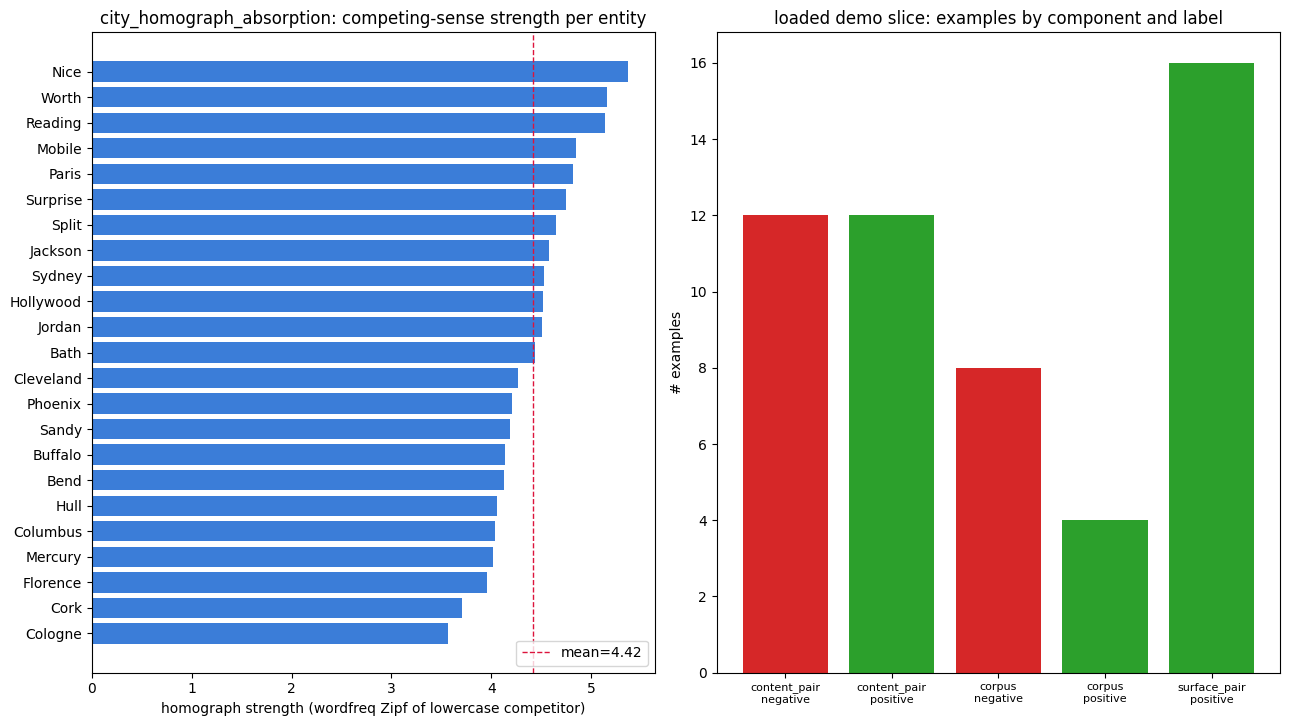

loaded slice composition:
    row_type   output  n
content_pair negative 12
content_pair positive 12
      corpus negative  8
      corpus positive  4
surface_pair positive 16

negative families: {'other_place': 12, 'homograph_competitor': 6, 'easy': 2}


In [12]:
# Summary visualisation: (1) the homograph strength (wordfreq Zipf of the competing common word) for the
# entities in the demo hierarchy -- higher = stronger competing sense = more likely to absorb the parent;
# (2) the example breakdown of the loaded slice by component and label.
import matplotlib.pyplot as plt

# (1) homograph strengths for the demo hierarchy's gazetteer
ent_strength = sorted(((e["surface"], e["strength"]) for e in ENTITIES[DEMO_HIERARCHY]),
                      key=lambda x: x[1])
names = [n for n, _ in ent_strength]
vals = [v for _, v in ent_strength]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, max(4, 0.32 * len(names))))
ax1.barh(names, vals, color="#3b7dd8")
ax1.set_xlabel("homograph strength (wordfreq Zipf of lowercase competitor)")
ax1.set_title(f"{DATASET_NAME[DEMO_HIERARCHY]}: competing-sense strength per entity")
ax1.axvline(np.mean(vals), color="crimson", ls="--", lw=1, label=f"mean={np.mean(vals):.2f}")
ax1.legend(loc="lower right")

# (2) loaded-slice composition by (row_type, output)
comp = Counter((e["metadata_row_type"], e["output"]) for e in ds["examples"])
labels = sorted(comp)
ax2.bar([f"{rt}\n{o}" for rt, o in labels], [comp[k] for k in labels],
        color=["#2ca02c" if o == "positive" else "#d62728" for _, o in labels])
ax2.set_ylabel("# examples")
ax2.set_title("loaded demo slice: examples by component and label")
ax2.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

# compact text summary
print("loaded slice composition:")
summary = pd.DataFrame(
    [{"row_type": rt, "output": o, "n": comp[(rt, o)]} for rt, o in labels])
print(summary.to_string(index=False))
neg_fam = Counter(e["metadata_neg_family"] for e in ds["examples"]
                  if e["output"] == "negative")
print("\nnegative families:", dict(neg_fam))
